# Clustering Analysis

## Gym Members Exercise Dataset

**Author:** Sarah Suliman  
**Course:** CSPB 4502: Data Mining  
**Project:** Discovering Fitness Profiles and Workout Performance Patterns Through Data Mining

## 1. Project Objective

The objective of this notebook is to identify natural groups of gym members using K-Means clustering. Unlike supervised learning, clustering does not use labeled outcomes. Instead, it groups individuals with similar workout characteristics to discover meaningful fitness profiles.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
DATA_PATH = Path("../data/processed/gym_members_exercise_cleaned.csv")
FIGURES_DIR = Path("../figures")
MODELS_DIR = Path("../models")

df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Heart_Rate_Reserve,Calories_Per_Hour,Water_Intake_Per_Hour,BMI_Category
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,120,776.923077,2.071006,Obese
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,113,679.230769,1.615385,Obese
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,113,609.909910,2.072072,Normal
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,134,901.694915,3.559322,Underweight
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,120,868.750000,4.375000,Underweight


## 2. Select Features for Clustering

In [3]:
features = [
    "BMI",
    "Workout_Frequency (days/week)",
    "Fat_Percentage",
    "Calories_Burned"
]

X = df[features]

X.head()

,BMI,Workout_Frequency (days/week),Fat_Percentage,Calories_Burned
0,30.20,4,12.6,1313.0
1,32.00,4,33.9,883.0
2,24.71,4,33.4,677.0
3,18.41,3,28.8,532.0
4,14.39,3,29.2,556.0


These four variables were selected because they represent body composition, workout consistency, and exercise performance. Together they provide a meaningful basis for identifying groups of similar gym members.

## 3. Standardize Features

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    MODELS_DIR / "clustering_scaler.joblib"
)

['../models/clustering_scaler.joblib']

Feature scaling ensures that variables measured on different scales contribute equally during clustering.

## 4. Determine the Optimal Number of Clusters

In [5]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

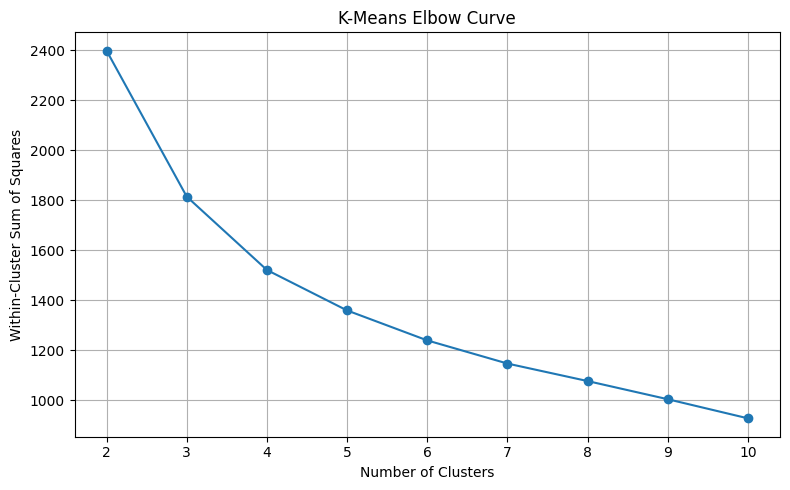

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.title("K-Means Elbow Curve")

plt.xlabel("Number of Clusters")

plt.ylabel("Within-Cluster Sum of Squares")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "kmeans_elbow_curve.png",
    dpi=300
)

plt.show()

The elbow curve indicates that four clusters provide a good balance between model complexity and within-cluster variation.

## 5. Train Final K-Means Model

In [7]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [8]:
joblib.dump(
    kmeans,
    MODELS_DIR / "kmeans_model.joblib"
)

['../models/kmeans_model.joblib']

In [9]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

print(f"Silhouette Score: {silhouette:.3f}")

Silhouette Score: 0.271


The silhouette score evaluates how well-separated the clusters are. Higher values indicate stronger cluster separation and better clustering quality.

## 6. Visualize Clusters Using PCA

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

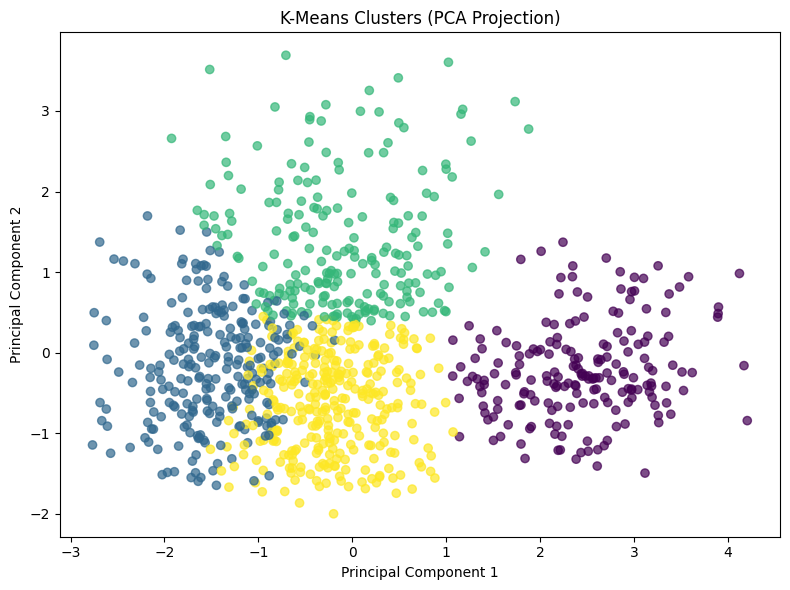

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    alpha=0.7
)

plt.title("K-Means Clusters (PCA Projection)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "kmeans_clusters_pca.png",
    dpi=300
)

plt.show()

The PCA projection provides a two-dimensional visualization of the cluster assignments. Although dimensionality reduction simplifies the feature space, the visualization demonstrates clear separation among the identified fitness profiles.

## 7. Cluster Profiles

In [12]:
cluster_summary = (
    df.groupby("Cluster")[features]
      .mean()
      .round(2)
)

cluster_summary

,BMI,Workout_Frequency (days/week),Fat_Percentage,Calories_Burned
Cluster,,,,
0,24.75,4.52,14.91,1265.98
1,22.53,2.43,28.73,633.42
2,33.93,3.10,25.58,885.49
3,20.94,3.44,27.76,912.44


The cluster profile table summarizes the average characteristics of each fitness group. Differences in BMI, workout frequency, body fat percentage, and calories burned help distinguish the four identified clusters and provide insight into varying exercise behaviors.

## 8. Key Findings

- Four distinct fitness profiles were identified using K-Means clustering.
- Feature scaling improved clustering performance by ensuring equal contribution from each variable.
- The elbow curve supported selecting four clusters.
- PCA visualization demonstrated meaningful separation between clusters.
- Cluster profiles revealed differences in workout habits and physiological characteristics that can support future fitness recommendations.